In [2]:
import os

In [3]:
# ============================================================================
# CELL 1: Setup & Imports
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
# ============================================================================
# CELL 2: Dataset Class
# ============================================================================
class ScanpathDataset(Dataset):
    def __init__(self, images_dir, scanpaths_json, transform=None, max_fixations=30):  # Increased default
        self.images_dir = Path(images_dir)
        self.transform = transform
        self.max_fixations = max_fixations
        
        # Load scanpaths
        with open(scanpaths_json, 'r') as f:
            self.scanpaths_data = json.load(f)
        
        # Create list of (image_path, variation_key, scanpath) tuples
        self.samples = []
        for img_name, variations in self.scanpaths_data.items():
            img_path = self.images_dir / img_name
            if not img_path.exists():
                print(f"Warning: Image {img_path} not found, skipping...")
                continue
            
            for var_key, scanpath in variations.items():
                if len(scanpath) > 0:  # Only add if scanpath has fixations
                    self.samples.append((img_path, var_key, scanpath))
        
        print(f"Loaded {len(self.samples)} samples from {len(self.scanpaths_data)} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, var_key, scanpath = self.samples[idx]
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        orig_width, orig_height = image.size
        
        # Extract and normalize coordinates [x, y]
        coords = []
        for fixation in scanpath:
            x, y = fixation[0], fixation[1]
            # Normalize to [0, 1]
            norm_x = x / orig_width
            norm_y = y / orig_height
            coords.append([norm_x, norm_y])
        
        # Pad or truncate to max_fixations
        num_fixations = len(coords)
        if num_fixations < self.max_fixations:
            # Pad with zeros
            coords.extend([[0.0, 0.0]] * (self.max_fixations - num_fixations))
            mask = [1] * num_fixations + [0] * (self.max_fixations - num_fixations)
        else:
            coords = coords[:self.max_fixations]
            mask = [1] * self.max_fixations
        
        coords = torch.tensor(coords, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        
        # Transform image
        if self.transform:
            image = self.transform(image)
        
        return {
            'image': image,
            'scanpath': coords,
            'mask': mask,
            'orig_size': torch.tensor([orig_width, orig_height], dtype=torch.float32),
            'num_fixations': torch.tensor(num_fixations, dtype=torch.long)
        }

In [5]:
# ============================================================================
# CELL 3: Enhanced Model Architecture
# ============================================================================
class ScanpathPredictor(nn.Module):
    def __init__(self, max_fixations=30, hidden_dim=512, num_layers=2):  # Increased default
        super(ScanpathPredictor, self).__init__()
        self.max_fixations = max_fixations
        self.hidden_dim = hidden_dim
        
        # CNN feature extractor (ResNet50 backbone)
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        # Remove the final FC layer
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        
        # Freeze early layers for faster training
        for param in list(self.feature_extractor.parameters())[:-20]:
            param.requires_grad = False
        
        # Feature dimension from ResNet50
        self.feature_dim = 2048
        
        # LSTM for sequential scanpath prediction
        self.lstm = nn.LSTM(
            input_size=self.feature_dim + 2,  # Image features + previous coords
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Output layer to predict (x, y) coordinates
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2),
            nn.Sigmoid()  # Output in [0, 1] range
        )
        
        # EOS (End of Sequence) predictor
        self.eos_predictor = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()  # Probability of ending sequence
        )
    
    def forward(self, images, teacher_forcing_ratio=0.5, target_scanpath=None, 
                dynamic_length=False, min_fixations=10, max_generation_length=None):
        batch_size = images.size(0)
        generation_length = max_generation_length or self.max_fixations
        
        # Extract image features
        img_features = self.feature_extractor(images)  # [B, 2048, 1, 1]
        img_features = img_features.view(batch_size, -1)  # [B, 2048]
        
        # Initialize LSTM hidden state
        h0 = torch.zeros(2, batch_size, self.hidden_dim).to(images.device)
        c0 = torch.zeros(2, batch_size, self.hidden_dim).to(images.device)
        
        # Generate scanpath sequentially
        outputs = []
        eos_outputs = []
        prev_coords = torch.zeros(batch_size, 2).to(images.device)  # Start at (0, 0)
        
        for t in range(generation_length):
            # Combine image features with previous coordinates
            lstm_input = torch.cat([img_features, prev_coords], dim=1)  # [B, 2050]
            lstm_input = lstm_input.unsqueeze(1)  # [B, 1, 2050]
            
            # LSTM step
            lstm_out, (h0, c0) = self.lstm(lstm_input, (h0, c0))
            lstm_out = lstm_out.squeeze(1)  # [B, hidden_dim]
            
            # Predict coordinates and EOS probability
            coords = self.fc_out(lstm_out)  # [B, 2]
            eos_prob = self.eos_predictor(lstm_out)  # [B, 1]
            
            outputs.append(coords)
            eos_outputs.append(eos_prob)
            
            # Early stopping based on EOS prediction (during inference)
            if dynamic_length and not self.training and t >= min_fixations:
                # Stop if EOS probability > 0.5 for all samples in batch
                if torch.all(eos_prob > 0.5):
                    break
            
            # Teacher forcing during training
            if self.training and target_scanpath is not None and t < target_scanpath.size(1) and random.random() < teacher_forcing_ratio:
                prev_coords = target_scanpath[:, t, :]
            else:
                prev_coords = coords
        
        # Stack outputs
        outputs = torch.stack(outputs, dim=1)  # [B, seq_len, 2]
        eos_outputs = torch.stack(eos_outputs, dim=1)  # [B, seq_len, 1]
        
        return outputs, eos_outputs

In [6]:
# ============================================================================
# CELL 4: Data Loading & Preparation
# ============================================================================
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset with increased max_fixations
dataset = ScanpathDataset(
    images_dir='dataset/displayFonts',
    scanpaths_json='OUTPUT_SCANPATHS/scanpathsCAREFUL.json',
    transform=transform,
    max_fixations=30  # Increased from 10 to 30
)

# Split into train and validation (80-20 split)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create data loaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Max fixations per scanpath: 30")

Loaded 402 samples from 103 images
Training samples: 321
Validation samples: 81
Batch size: 8
Max fixations per scanpath: 30


In [7]:
# ============================================================================
# CELL 5: Enhanced Training Functions
# ============================================================================
def masked_loss_with_eos(predicted_coords, target_coords, predicted_eos, mask):
    """Enhanced loss function with EOS prediction"""
    # Coordinate loss (MSE)
    coord_loss = (predicted_coords - target_coords) ** 2  # [B, max_fixations, 2]
    coord_loss = coord_loss.mean(dim=-1)  # [B, max_fixations]
    coord_loss = coord_loss * mask
    
    # EOS loss (BCE) - target EOS should be 1 where mask transitions from 1 to 0
    target_eos = torch.zeros_like(mask)
    for b in range(mask.size(0)):
        # Find the last valid fixation
        valid_indices = (mask[b] == 1).nonzero(as_tuple=False).flatten()
        if len(valid_indices) > 0:
            last_valid_idx = valid_indices[-1].item()
            if last_valid_idx < mask.size(1) - 1:  # If not at the end
                target_eos[b, last_valid_idx + 1] = 1.0
    
    eos_loss = nn.BCELoss(reduction='none')(predicted_eos.squeeze(-1), target_eos)
    
    # Combine losses
    num_valid = mask.sum()
    if num_valid > 0:
        total_coord_loss = coord_loss.sum() / num_valid
    else:
        total_coord_loss = coord_loss.sum()
    
    total_eos_loss = eos_loss.mean()
    
    return total_coord_loss + 0.1 * total_eos_loss

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    num_batches = 0
    
    for batch in loader:
        images = batch['image'].to(device)
        scanpaths = batch['scanpath'].to(device)
        masks = batch['mask'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with teacher forcing
        predictions, eos_predictions = model(images, teacher_forcing_ratio=0.5, target_scanpath=scanpaths)
        
        # Compute loss
        loss = masked_loss_with_eos(predictions, scanpaths, eos_predictions, masks)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def validate(model, loader, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            scanpaths = batch['scanpath'].to(device)
            masks = batch['mask'].to(device)
            
            # Forward pass without teacher forcing
            predictions, eos_predictions = model(images, teacher_forcing_ratio=0.0)
            
            # Compute loss
            loss = masked_loss_with_eos(predictions, scanpaths, eos_predictions, masks)
            
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

In [8]:
# ============================================================================
# CELL 6: Training Loop
# ============================================================================
# Initialize model with more fixations
model = ScanpathPredictor(max_fixations=30, hidden_dim=512, num_layers=2)
model = model.to(device)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

# Training
num_epochs = 20
best_val_loss = float('inf')
train_losses = []
val_losses = []

print("Starting training with enhanced model...")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = validate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_scanpath_model_enhanced.pth')
        print(f"  -> Saved best model (val_loss: {val_loss:.6f})")

print("\nTraining completed!")

c:\Users\SAGAR\.pyenv\pyenv-win\versions\3.8.10\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training with enhanced model...
Epoch 1/20 - Train Loss: 0.061912, Val Loss: 0.056813
  -> Saved best model (val_loss: 0.056813)
Epoch 2/20 - Train Loss: 0.048726, Val Loss: 0.045112
  -> Saved best model (val_loss: 0.045112)
Epoch 3/20 - Train Loss: 0.043072, Val Loss: 0.043015
  -> Saved best model (val_loss: 0.043015)
Epoch 4/20 - Train Loss: 0.040087, Val Loss: 0.039206
  -> Saved best model (val_loss: 0.039206)
Epoch 5/20 - Train Loss: 0.038381, Val Loss: 0.039228
Epoch 6/20 - Train Loss: 0.035546, Val Loss: 0.035100
  -> Saved best model (val_loss: 0.035100)
Epoch 7/20 - Train Loss: 0.033909, Val Loss: 0.032702
  -> Saved best model (val_loss: 0.032702)
Epoch 8/20 - Train Loss: 0.032498, Val Loss: 0.033629
Epoch 9/20 - Train Loss: 0.030925, Val Loss: 0.028915
  -> Saved best model (val_loss: 0.028915)
Epoch 10/20 - Train Loss: 0.028100, Val Loss: 0.029533
Epoch 11/20 - Train Loss: 0.027236, Val Loss: 0.028225
  -> Saved best model (val_loss: 0.028225)
Epoch 12/20 - Train

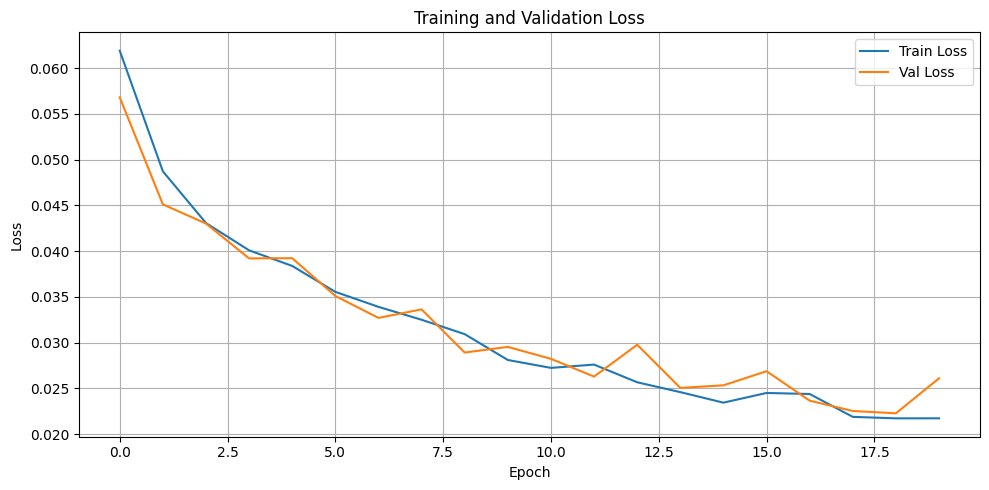

In [9]:
# ============================================================================
# CELL 7: Plot Training Curves
# ============================================================================
# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================================
# CELL 8: Enhanced Inference Functions
# ============================================================================
def predict_scanpath_variable_length(model, image_path, transform, device, 
                                    num_variations=1, min_fixations=10, max_fixations=50):
    """Generate variable-length scanpath predictions for a single image"""
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    orig_width, orig_height = image.size
    
    # Transform for model input
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    predictions = []
    with torch.no_grad():
        for _ in range(num_variations):
            # Generate scanpath with dynamic length
            pred_scanpath, eos_probs = model(
                image_tensor, 
                teacher_forcing_ratio=0.0,
                dynamic_length=True,
                min_fixations=min_fixations,
                max_generation_length=max_fixations
            )
            pred_scanpath = pred_scanpath.squeeze(0).cpu().numpy()  # [seq_len, 2]
            eos_probs = eos_probs.squeeze(0).cpu().numpy()  # [seq_len, 1]
            
            # Find actual sequence length based on EOS predictions
            actual_length = max_fixations
            for i in range(min_fixations, len(eos_probs)):
                if eos_probs[i] > 0.5:  # EOS threshold
                    actual_length = i + 1
                    break
            
            # Take only the actual sequence
            pred_scanpath = pred_scanpath[:actual_length]
            
            # Denormalize coordinates
            denorm_scanpath = []
            for coords in pred_scanpath:
                x = coords[0] * orig_width
                y = coords[1] * orig_height
                # Filter out invalid coordinates (too close to 0,0)
                if x > 10 or y > 10:  # Only add if not near origin
                    denorm_scanpath.append([x, y])
            
            predictions.append(denorm_scanpath)
    
    return predictions, (orig_width, orig_height), image

def predict_scanpath_fixed_length(model, image_path, transform, device, 
                                 num_variations=1, num_fixations=30):
    """Generate fixed-length scanpath predictions (original function)"""
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    orig_width, orig_height = image.size
    
    # Transform for model input
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    predictions = []
    with torch.no_grad():
        for _ in range(num_variations):
            # Generate scanpath
            pred_scanpath, _ = model(
                image_tensor, 
                teacher_forcing_ratio=0.0,
                max_generation_length=num_fixations
            )
            pred_scanpath = pred_scanpath.squeeze(0).cpu().numpy()  # [num_fixations, 2]
            
            # Denormalize coordinates
            denorm_scanpath = []
            for coords in pred_scanpath:
                x = coords[0] * orig_width
                y = coords[1] * orig_height
                denorm_scanpath.append([x, y])
            
            predictions.append(denorm_scanpath)
    
    return predictions, (orig_width, orig_height), image

def visualize_scanpath_with_fatigue(image, scanpath, fatigue_labels=None, output_path=None, title="Predicted Scanpath"):
    """Enhanced visualization with fatigue indication - red for fatigue points and segments"""
    # Convert PIL image to numpy array
    img_np = np.array(image)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img_np)
    
    # Filter out padded/invalid fixations
    valid_fixations = []
    valid_fatigue_labels = []
    for i, (x, y) in enumerate(scanpath):
        # More restrictive filtering
        if (x > img_np.shape[1] * 0.02 or y > img_np.shape[0] * 0.02) and \
           (x < img_np.shape[1] * 0.98 and y < img_np.shape[0] * 0.98):
            valid_fixations.append([x, y])
            if fatigue_labels and i < len(fatigue_labels):
                valid_fatigue_labels.append(fatigue_labels[i])
            else:
                valid_fatigue_labels.append(0)  # Default to not fatigued
    
    print(f"Generated {len(valid_fixations)} valid fixations")
    
    if len(valid_fixations) > 0:
        valid_fixations = np.array(valid_fixations)
        
        # Draw connecting lines with fatigue coloring
        if len(valid_fixations) > 1:
            for i in range(len(valid_fixations) - 1):
                # Check if current or next point is fatigue
                current_fatigue = valid_fatigue_labels[i] if i < len(valid_fatigue_labels) else 0
                next_fatigue = valid_fatigue_labels[i+1] if (i+1) < len(valid_fatigue_labels) else 0
                
                # Line is red if either point is fatigue, blue otherwise
                line_color = 'red' if (current_fatigue or next_fatigue) else 'blue'
                line_width = 3 if (current_fatigue or next_fatigue) else 2
                
                ax.plot(
                    [valid_fixations[i][0], valid_fixations[i+1][0]],
                    [valid_fixations[i][1], valid_fixations[i+1][1]],
                    color=line_color, linewidth=line_width, alpha=0.8
                )
        
        # Draw fixation points with fatigue coloring
        for i, (x, y) in enumerate(valid_fixations):
            is_fatigue = valid_fatigue_labels[i] if i < len(valid_fatigue_labels) else 0
            
            if is_fatigue:
                # Fatigue points: red with larger size
                ax.plot(x, y, 'ro', markersize=12, markeredgewidth=3, 
                       markeredgecolor='darkred', markerfacecolor='red', alpha=0.9)
                # White text on red background
                ax.text(x, y, str(i+1), color='white', fontsize=10, 
                       fontweight='bold', ha='center', va='center')
            else:
                # Normal points: green with white border
                ax.plot(x, y, 'go', markersize=10, markeredgewidth=2, 
                       markeredgecolor='white', markerfacecolor='green', alpha=0.8)
                # Black text on green background
                ax.text(x, y, str(i+1), color='black', fontsize=9, 
                       fontweight='bold', ha='center', va='center')
        
        # Count fatigue points
        num_fatigue = sum(valid_fatigue_labels) if fatigue_labels else 0
        fatigue_info = f" ({num_fatigue} fatigue points)" if fatigue_labels else ""
    else:
        fatigue_info = ""
    
    ax.set_title(f"{title} ({len(valid_fixations)} fixations{fatigue_info})", 
                fontsize=14, fontweight='bold')
    ax.axis('off')
    
    # Add legend if fatigue labels are provided
    if fatigue_labels:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', edgecolor='white', label='Normal Fixation'),
            Patch(facecolor='red', edgecolor='darkred', label='Fatigue Fixation'),
            plt.Line2D([0], [0], color='blue', linewidth=2, label='Normal Segment'),
            plt.Line2D([0], [0], color='red', linewidth=3, label='Fatigue Segment')
        ]
        ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"Saved visualization to {output_path}")
    else:
        plt.show()

def visualize_scanpath_enhanced(image, scanpath, output_path, title="Predicted Scanpath"):
    """Legacy function - calls the new fatigue-aware visualization without fatigue labels"""
    visualize_scanpath_with_fatigue(image, scanpath, fatigue_labels=None, 
                                   output_path=output_path, title=title)

In [11]:
# ============================================================================
# CELL 9: Evaluation Metrics
# ============================================================================
def compute_fixation_variance(scanpath):
    """Compute variance of fixation coordinates"""
    # Filter out padded fixations
    valid_fixations = []
    for x, y in scanpath:
        if x > 5 or y > 5:
            valid_fixations.append([x, y])
    
    if len(valid_fixations) < 2:
        return 0.0, 0.0
    
    valid_fixations = np.array(valid_fixations)
    var_x = np.var(valid_fixations[:, 0])
    var_y = np.var(valid_fixations[:, 1])
    
    return var_x, var_y

def compute_scanpath_length(scanpath):
    """Compute total length of scanpath (sum of Euclidean distances)"""
    # Filter out padded fixations
    valid_fixations = []
    for x, y in scanpath:
        if x > 5 or y > 5:
            valid_fixations.append([x, y])
    
    if len(valid_fixations) < 2:
        return 0.0
    
    total_length = 0.0
    for i in range(len(valid_fixations) - 1):
        x1, y1 = valid_fixations[i]
        x2, y2 = valid_fixations[i + 1]
        dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        total_length += dist
    
    return total_length

def evaluate_scanpaths(scanpaths_list):
    """Compute evaluation metrics for a list of scanpaths"""
    all_variances_x = []
    all_variances_y = []
    all_lengths = []
    all_num_fixations = []
    
    for scanpath in scanpaths_list:
        var_x, var_y = compute_fixation_variance(scanpath)
        length = compute_scanpath_length(scanpath)
        
        # Count valid fixations
        valid_count = sum(1 for x, y in scanpath if x > 5 or y > 5)
        
        all_variances_x.append(var_x)
        all_variances_y.append(var_y)
        all_lengths.append(length)
        all_num_fixations.append(valid_count)
    
    metrics = {
        'avg_variance_x': np.mean(all_variances_x),
        'avg_variance_y': np.mean(all_variances_y),
        'avg_length': np.mean(all_lengths),
        'std_length': np.std(all_lengths),
        'avg_num_fixations': np.mean(all_num_fixations),
        'std_num_fixations': np.std(all_num_fixations)
    }
    
    return metrics

def print_metrics(metrics, title="Evaluation Metrics"):
    """Pretty print evaluation metrics"""
    print(f"\n{'='*50}")
    print(f"{title}")
    print(f"{'='*50}")
    print(f"Average Variance X: {metrics['avg_variance_x']:.2f}")
    print(f"Average Variance Y: {metrics['avg_variance_y']:.2f}")
    print(f"Average Scanpath Length: {metrics['avg_length']:.2f} pixels")
    print(f"Std Scanpath Length: {metrics['std_length']:.2f} pixels")
    print(f"Average Number of Fixations: {metrics['avg_num_fixations']:.1f}")
    print(f"Std Number of Fixations: {metrics['std_num_fixations']:.1f}")
    print(f"{'='*50}\n")

In [12]:
# ============================================================================
# CELL 10: Complete Enhanced Inference & Evaluation Pipeline
# ============================================================================
def run_inference_and_evaluation_enhanced(model, test_image_path, output_dir='outputs/predictions', 
                                         num_variations=1, mode='variable', min_fixations=10, max_fixations=50):
    """
    Complete pipeline with support for both variable and fixed length generation
    
    Args:
        model: Trained model
        test_image_path: Path to test image
        output_dir: Directory to save outputs
        num_variations: Number of scanpath variations to generate
        mode: 'variable' for dynamic length, 'fixed' for fixed length
        min_fixations: Minimum number of fixations (for variable mode)
        max_fixations: Maximum number of fixations
    """
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Get image name
    image_name = Path(test_image_path).stem
    
    print(f"\n{'='*60}")
    print(f"Processing: {test_image_path}")
    print(f"Mode: {mode}")
    print(f"{'='*60}")
    
    # Generate predictions based on mode
    if mode == 'variable':
        print(f"Generating {num_variations} variable-length scanpath(s)...")
        print(f"Min fixations: {min_fixations}, Max fixations: {max_fixations}")
        predictions, img_size, original_image = predict_scanpath_variable_length(
            model, test_image_path, transform, device, 
            num_variations, min_fixations, max_fixations
        )
    else:  # fixed mode
        print(f"Generating {num_variations} fixed-length scanpath(s) with {max_fixations} fixations...")
        predictions, img_size, original_image = predict_scanpath_fixed_length(
            model, test_image_path, transform, device, 
            num_variations, max_fixations
        )
    
    print(f"Image size: {img_size[0]}x{img_size[1]} pixels")
    print(f"Generated {len(predictions)} scanpath(s)")
    
    # Visualize each variation
    all_scanpaths = []
    for i, scanpath in enumerate(predictions):
        output_path = os.path.join(output_dir, f'{image_name}_{mode}_variation_{i+1}.png')
        visualize_scanpath_enhanced(
            original_image, 
            scanpath, 
            output_path,
            title=f"Predicted Scanpath - {image_name} ({mode.title()}, Var {i+1})"
        )
        all_scanpaths.append(scanpath)
    
    # Compute metrics
    metrics = evaluate_scanpaths(all_scanpaths)
    print_metrics(metrics, title=f"Metrics for {image_name} ({mode.title()} Mode)")
    
    return predictions, metrics

In [13]:
# ============================================================================
# CELL 11: Load Model and Test Functions
# ============================================================================
# Load the best trained model (try enhanced first, fallback to original)
try:
    model.load_state_dict(torch.load('best_scanpath_model_enhanced.pth'))
    print("Loaded enhanced model")
except:
    try:
        model.load_state_dict(torch.load('best_scanpath_model.pth'))
        print("Loaded original model")
    except:
        print("No trained model found. Please train the model first.")

model.eval()

Loaded enhanced model


C:\Users\SAGAR\AppData\Local\Temp\ipykernel_55736\1352007662.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_scanpath_model_enhanc

ScanpathPredictor(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [14]:
# Test on a single image with both modes
test_image_path = 'dataset/displayFonts/6.png'

# Test 1: Variable length generation (10-50 fixations)
print("=== Testing Variable Length Generation ===")
predictions_var, metrics_var = run_inference_and_evaluation_enhanced(
    model=model,
    test_image_path=test_image_path,
    output_dir='outputs/predictions_enhanced',
    num_variations=1,  # Generate 3 variations
    mode='variable',
    min_fixations=15,  # Minimum 15 fixations
    max_fixations=20   # Maximum 50 fixations
)

# Test 2: Fixed length generation (exactly 30 fixations)
print("\n=== Testing Fixed Length Generation ===")
predictions_fixed, metrics_fixed = run_inference_and_evaluation_enhanced(
    model=model,
    test_image_path=test_image_path,
    output_dir='outputs/predictions_enhanced',
    num_variations=1,  # Generate 2 variations
    mode='fixed',
    max_fixations=30   # Exactly 30 fixations
)

print("\n✓ Enhanced inference completed successfully!")
print(f"✓ Variable-length visualizations saved with 15-50 fixations")
print(f"✓ Fixed-length visualizations saved with exactly 30 fixations")
print(f"✓ All outputs saved to: outputs/predictions_enhanced/")

=== Testing Variable Length Generation ===

Processing: dataset/displayFonts/6.png
Mode: variable
Generating 1 variable-length scanpath(s)...
Min fixations: 15, Max fixations: 20
Image size: 1190x1684 pixels
Generated 1 scanpath(s)
Generated 20 valid fixations
Saved visualization to outputs/predictions_enhanced\6_variable_variation_1.png

Metrics for 6 (Variable Mode)
Average Variance X: 53980.95
Average Variance Y: 52712.88
Average Scanpath Length: 3791.97 pixels
Std Scanpath Length: 0.00 pixels
Average Number of Fixations: 20.0
Std Number of Fixations: 0.0


=== Testing Fixed Length Generation ===

Processing: dataset/displayFonts/6.png
Mode: fixed
Generating 1 fixed-length scanpath(s) with 30 fixations...
Image size: 1190x1684 pixels
Generated 1 scanpath(s)
Generated 30 valid fixations
Saved visualization to outputs/predictions_enhanced\6_fixed_variation_1.png

Metrics for 6 (Fixed Mode)
Average Variance X: 50526.05
Average Variance Y: 44813.15
Average Scanpath Length: 3917.55 pixel

# FATIGUE HERE


In [15]:
# ============================================================================
# CELL 12: Fatigue Prediction Dataset
# ============================================================================

class FatigueDataset(Dataset):
    def __init__(self, images_dir, scanpaths_json, transform=None, max_fixations=30):
        self.images_dir = Path(images_dir)
        self.transform = transform
        self.max_fixations = max_fixations
        
        # Load scanpaths with labels
        with open(scanpaths_json, 'r') as f:
            self.scanpaths_data = json.load(f)
        
        # Create list of (image_path, variation_key, coords, labels)
        self.samples = []
        for img_name, variations in self.scanpaths_data.items():
            img_path = self.images_dir / img_name
            if not img_path.exists():
                print(f"Warning: Image {img_path} not found, skipping...")
                continue
            
            for var_key, scanpath in variations.items():
                if len(scanpath) > 0:
                    coords = []
                    labels = []
                    for fixation in scanpath:
                        x, y = fixation[0], fixation[1]
                        label = 1 if fixation[3] == "Fatigue" else 0  # 1 for Fatigue, 0 for Good
                        coords.append([x, y])
                        labels.append(label)
                    self.samples.append((img_path, var_key, coords, labels))
        
        print(f"Loaded {len(self.samples)} samples for fatigue prediction from {len(self.scanpaths_data)} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, var_key, coords, labels = self.samples[idx]
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        orig_width, orig_height = image.size
        
        # Create copies to avoid modifying the original lists
        norm_coords = []
        labels_copy = labels.copy()  # Important: create a copy!
        
        # Normalize coordinates
        for x, y in coords:
            norm_x = x / orig_width
            norm_y = y / orig_height
            norm_coords.append([norm_x, norm_y])
        
        # Pad or truncate (now working with copies)
        num_fixations = len(norm_coords)
        if num_fixations < self.max_fixations:
            norm_coords.extend([[0.0, 0.0]] * (self.max_fixations - num_fixations))
            labels_copy.extend([0] * (self.max_fixations - num_fixations))
            mask = [1] * num_fixations + [0] * (self.max_fixations - num_fixations)
        else:
            norm_coords = norm_coords[:self.max_fixations]
            labels_copy = labels_copy[:self.max_fixations]
            mask = [1] * self.max_fixations
        
        # Validation checks
        assert len(norm_coords) == self.max_fixations, f"Coords length mismatch: {len(norm_coords)} != {self.max_fixations}"
        assert len(labels_copy) == self.max_fixations, f"Labels length mismatch: {len(labels_copy)} != {self.max_fixations}"
        assert len(mask) == self.max_fixations, f"Mask length mismatch: {len(mask)} != {self.max_fixations}"
        
        norm_coords = torch.tensor(norm_coords, dtype=torch.float32)
        labels_tensor = torch.tensor(labels_copy, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        
        # Transform image
        if self.transform:
            image = self.transform(image)
        
        return {
            'image': image,
            'scanpath': norm_coords,
            'labels': labels_tensor,
            'mask': mask,
            'orig_size': torch.tensor([orig_width, orig_height], dtype=torch.float32),
            'num_fixations': torch.tensor(num_fixations, dtype=torch.long)
        }

# Create fatigue dataset
fatigue_dataset = FatigueDataset(
    images_dir='dataset/displayFonts',
    scanpaths_json='OUTPUT_SCANPATHS/scanpathsCAREFUL.json',
    transform=transform,
    max_fixations=30
)

# Split into train and val
train_size = int(0.8 * len(fatigue_dataset))
val_size = len(fatigue_dataset) - train_size
fatigue_train_dataset, fatigue_val_dataset = torch.utils.data.random_split(
    fatigue_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Data loaders
fatigue_train_loader = DataLoader(fatigue_train_dataset, batch_size=8, shuffle=True)
fatigue_val_loader = DataLoader(fatigue_val_dataset, batch_size=8, shuffle=False)

print(f"Fatigue training samples: {len(fatigue_train_dataset)}")
print(f"Fatigue validation samples: {len(fatigue_val_dataset)}")

Loaded 402 samples for fatigue prediction from 103 images
Fatigue training samples: 321
Fatigue validation samples: 81


In [16]:
# ============================================================================
# CELL 13: Fatigue Model Architecture
# ============================================================================

class FatiguePredictor(nn.Module):
    def __init__(self, hidden_dim=512, num_layers=2):
        super(FatiguePredictor, self).__init__()
        self.hidden_dim = hidden_dim
        
        # CNN feature extractor (ResNet50 backbone)
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        self.feature_dim = 2048
        
        # Freeze early layers
        for param in list(self.feature_extractor.parameters())[:-20]:
            param.requires_grad = False
        
        # LSTM for fatigue prediction
        self.lstm = nn.LSTM(
            input_size=self.feature_dim + 2,  # Image features + coords
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Output layer for binary fatigue probability
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Probability of fatigue
        )
    
    def forward(self, images, scanpaths):
        batch_size = images.size(0)
        
        # Extract image features
        img_features = self.feature_extractor(images)  # [B, 2048, 1, 1]
        img_features = img_features.view(batch_size, -1)  # [B, 2048]
        
        # Prepare input for LSTM: repeat img_features for each fixation and concat with coords
        seq_len = scanpaths.size(1)
        img_features_exp = img_features.unsqueeze(1).repeat(1, seq_len, 1)  # [B, seq_len, 2048]
        lstm_input = torch.cat([img_features_exp, scanpaths], dim=2)  # [B, seq_len, 2048+2]
        
        # LSTM
        lstm_out, _ = self.lstm(lstm_input)  # [B, seq_len, hidden_dim]
        
        # Predict fatigue probabilities
        preds = self.fc_out(lstm_out)  # [B, seq_len, 1]
        
        return preds

In [17]:
# ============================================================================
# CELL 14: Training Functions for Fatigue Model
# ============================================================================

def train_fatigue_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    num_batches = 0
    
    for batch in loader:
        images = batch['image'].to(device)
        scanpaths = batch['scanpath'].to(device)
        labels = batch['labels'].to(device)
        masks = batch['mask'].to(device)
        
        optimizer.zero_grad()
        
        preds = model(images, scanpaths)
        
        # Binary Cross Entropy with mask
        bce = nn.BCELoss(reduction='none')(preds.squeeze(-1), labels)
        bce = bce * masks
        num_valid = masks.sum()
        loss = bce.sum() / num_valid if num_valid > 0 else bce.sum()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def validate_fatigue(model, loader, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            scanpaths = batch['scanpath'].to(device)
            labels = batch['labels'].to(device)
            masks = batch['mask'].to(device)
            
            preds = model(images, scanpaths)
            
            bce = nn.BCELoss(reduction='none')(preds.squeeze(-1), labels)
            bce = bce * masks
            num_valid = masks.sum()
            loss = bce.sum() / num_valid if num_valid > 0 else bce.sum()
            
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

In [18]:
# ============================================================================
# CELL 15: Train Fatigue Model
# ============================================================================

fatigue_model = FatiguePredictor().to(device)
fatigue_optimizer = optim.Adam(fatigue_model.parameters(), lr=0.001)
num_epochs = 20  # Adjust as needed

best_val_loss = float('inf')
for epoch in range(num_epochs):
    train_loss = train_fatigue_epoch(fatigue_model, fatigue_train_loader, fatigue_optimizer, device)
    val_loss = validate_fatigue(fatigue_model, fatigue_val_loader, device)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(fatigue_model.state_dict(), 'best_fatigue_model.pth')
        print("Saved best fatigue model")

Epoch 1/20, Train Loss: 0.5431, Val Loss: 0.3157
Saved best fatigue model
Epoch 2/20, Train Loss: 0.3678, Val Loss: 0.1967
Saved best fatigue model
Epoch 2/20, Train Loss: 0.3678, Val Loss: 0.1967
Saved best fatigue model
Epoch 3/20, Train Loss: 0.3094, Val Loss: 0.1523
Saved best fatigue model
Epoch 3/20, Train Loss: 0.3094, Val Loss: 0.1523
Saved best fatigue model
Epoch 4/20, Train Loss: 0.3039, Val Loss: 0.1726
Epoch 4/20, Train Loss: 0.3039, Val Loss: 0.1726
Epoch 5/20, Train Loss: 0.2313, Val Loss: 0.1244
Saved best fatigue model
Epoch 5/20, Train Loss: 0.2313, Val Loss: 0.1244
Saved best fatigue model
Epoch 6/20, Train Loss: 0.2371, Val Loss: 0.1256
Epoch 6/20, Train Loss: 0.2371, Val Loss: 0.1256
Epoch 7/20, Train Loss: 0.2385, Val Loss: 0.1591
Epoch 7/20, Train Loss: 0.2385, Val Loss: 0.1591
Epoch 8/20, Train Loss: 0.2671, Val Loss: 0.1044
Saved best fatigue model
Epoch 8/20, Train Loss: 0.2671, Val Loss: 0.1044
Saved best fatigue model
Epoch 9/20, Train Loss: 0.1546, Val Loss

In [19]:
# ============================================================================
# CELL 16: Fatigue Inference with Rule Enforcement
# ============================================================================

def predict_fatigue(model, image, scanpath, orig_width, orig_height, device, threshold=0.5):
    model.eval()
    
    # Prepare inputs
    norm_coords = []
    for x, y in scanpath:
        norm_x = x / orig_width
        norm_y = y / orig_height
        norm_coords.append([norm_x, norm_y])
    scanpath_tensor = torch.tensor([norm_coords], dtype=torch.float32).to(device)  # [1, len, 2]
    
    image = image.to(device).unsqueeze(0)  # [1, C, H, W]
    
    with torch.no_grad():
        preds = model(image, scanpath_tensor).squeeze(0).squeeze(-1).cpu().numpy()  # [len]
    
    # Binary predictions
    fatigue_labels = (preds > threshold).astype(int)
    
    # Enforce rule: no isolated fatigue (if 1, make sure next is 1; if isolated, set to 0)
    new_labels = fatigue_labels.copy()
    for i in range(len(fatigue_labels)):
        if fatigue_labels[i] == 1:
            if i + 1 < len(fatigue_labels) and fatigue_labels[i+1] == 0:
                new_labels[i] = 0  # Set isolated to 0
    return new_labels.tolist()

In [20]:
# ============================================================================
# CELL 17: Integrated Inference with Fatigue Prediction
# ============================================================================

def run_inference_with_fatigue(model, fatigue_model, test_image_path, output_dir='outputs/predictions', 
                               num_variations=1, mode='variable', min_fixations=10, max_fixations=30):
    os.makedirs(output_dir, exist_ok=True)
    
    image_name = Path(test_image_path).stem
    
    print(f"\n{'='*60}")
    print(f"Processing: {test_image_path}")
    print(f"Mode: {mode}")
    print(f"{'='*60}")
    
    # Generate scanpaths from first model
    if mode == 'variable':
        predictions, img_size, original_image = predict_scanpath_variable_length(
            model, test_image_path, transform, device, 
            num_variations, min_fixations, max_fixations
        )
    else:
        predictions, img_size, original_image = predict_scanpath_fixed_length(
            model, test_image_path, transform, device, 
            num_variations, max_fixations
        )
    
    print(f"Image size: {img_size[0]}x{img_size[1]} pixels")
    print(f"Generated {len(predictions)} scanpath(s)")
    
    # Apply fatigue prediction and create visualizations
    all_scanpaths = []
    for i, scanpath in enumerate(predictions):
        # Predict fatigue for this scanpath
        fatigue_labels = predict_fatigue(fatigue_model, transform(original_image), scanpath, img_size[0], img_size[1], device)
        print(f"Variation {i+1} fatigue labels: {fatigue_labels}")
        
        # Count fatigue points
        num_fatigue = sum(fatigue_labels)
        print(f"Variation {i+1}: {len(scanpath)} fixations, {num_fatigue} fatigue points")
        
        # Create fatigue-aware visualization
        output_path = os.path.join(output_dir, f'{image_name}_{mode}_variation_{i+1}_with_fatigue.png')
        visualize_scanpath_with_fatigue(
            original_image, 
            scanpath,
            fatigue_labels=fatigue_labels,
            output_path=output_path,
            title=f"Predicted Scanpath with Fatigue - {image_name} ({mode.title()}, Var {i+1})"
        )
        
        # Also create a regular visualization for comparison
        output_path_regular = os.path.join(output_dir, f'{image_name}_{mode}_variation_{i+1}_regular.png')
        visualize_scanpath_enhanced(
            original_image, 
            scanpath, 
            output_path_regular,
            title=f"Predicted Scanpath - {image_name} ({mode.title()}, Var {i+1})"
        )
        
        # Combine with duration and label for storage
        formatted_scanpath = []
        for j, (x, y) in enumerate(scanpath):
            label = "Fatigue" if j < len(fatigue_labels) and fatigue_labels[j] == 1 else "Good"
            formatted_scanpath.append([x, y, 200, label])
        
        all_scanpaths.append(formatted_scanpath)
    
    # Compute metrics
    metrics = evaluate_scanpaths(predictions)
    print_metrics(metrics, title=f"Metrics for {image_name} ({mode.title()} Mode)")
    
    return all_scanpaths, metrics

# Test with fatigue
test_image_path = 'dataset/displayFonts/image.png'

# Test variable length with fatigue
print("=== Testing Variable Length Generation with Fatigue ===")
predictions_var = run_inference_with_fatigue(
    model=model,
    fatigue_model=fatigue_model,
    test_image_path=test_image_path,
    output_dir='outputs/predictions_enhanced',
    num_variations=1,
    mode='variable',
    min_fixations=15,
    max_fixations=20
)

# Test fixed length with fatigue
print("\n=== Testing Fixed Length Generation with Fatigue ===")
predictions_fixed = run_inference_with_fatigue(
    model=model,
    fatigue_model=fatigue_model,
    test_image_path=test_image_path,
    output_dir='outputs/predictions_enhanced',
    num_variations=1,
    mode='fixed',
    max_fixations=30
)

print("\n✅ Integrated fatigue prediction completed successfully!")
print("✅ Fatigue visualizations:")
print("  🔴 RED points = Fatigue fixations")
print("  🟢 GREEN points = Normal fixations") 
print("  🔴 RED lines = Segments connecting to fatigue points")
print("  🔵 BLUE lines = Normal segments")
print(f"✅ All outputs saved to: outputs/predictions_enhanced/")

=== Testing Variable Length Generation with Fatigue ===

Processing: dataset/displayFonts/image.png
Mode: variable
Image size: 1873x975 pixels
Generated 1 scanpath(s)
Variation 1 fatigue labels: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Variation 1: 20 fixations, 16 fatigue points
Generated 20 valid fixations
Image size: 1873x975 pixels
Generated 1 scanpath(s)
Variation 1 fatigue labels: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Variation 1: 20 fixations, 16 fatigue points
Generated 20 valid fixations
Saved visualization to outputs/predictions_enhanced\image_variable_variation_1_with_fatigue.png
Generated 20 valid fixations
Saved visualization to outputs/predictions_enhanced\image_variable_variation_1_with_fatigue.png
Generated 20 valid fixations
Saved visualization to outputs/predictions_enhanced\image_variable_variation_1_regular.png

Metrics for image (Variable Mode)
Average Variance X: 96483.54
Average Variance Y: 16438.93
Average Scanpath Leng

# TEST

In [21]:
# Load trained scanpath and fatigue models if available
scanpath_model_path = 'best_scanpath_model_enhanced.pth'
fatigue_model_path = 'best_fatigue_model.pth'

# Load ScanpathPredictor model
model = ScanpathPredictor(max_fixations=30, hidden_dim=512, num_layers=2).to(device)
if os.path.exists(scanpath_model_path):
    model.load_state_dict(torch.load(scanpath_model_path, map_location=device))
    print("Loaded scanpath model from", scanpath_model_path)
else:
    print("Scanpath model checkpoint not found. Please train and save the model.")

# Load FatiguePredictor model
fatigue_model = FatiguePredictor().to(device)
if os.path.exists(fatigue_model_path):
    fatigue_model.load_state_dict(torch.load(fatigue_model_path, map_location=device))
    print("Loaded fatigue model from", fatigue_model_path)
else:
    print("Fatigue model checkpoint not found. Please train and save the model.")

model.eval()
fatigue_model.eval()

C:\Users\SAGAR\AppData\Local\Temp\ipykernel_55736\3993899208.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(scanpath_model_path, map_lo

Loaded scanpath model from best_scanpath_model_enhanced.pth
Loaded fatigue model from best_fatigue_model.pth
Loaded fatigue model from best_fatigue_model.pth


C:\Users\SAGAR\AppData\Local\Temp\ipykernel_55736\3993899208.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fatigue_model.load_state_dict(torch.load(fatigue_model_path

FatiguePredictor(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

In [22]:
# ============================================================================
# CELL 18: Test Fatigue Visualization Features
# ============================================================================

def test_fatigue_visualization():
    """Test the fatigue visualization with a clear example"""
    
    # Test different images
    # Get all images from the test folder
    test_folder = 'testers/'
    test_images = []
    
    if os.path.exists(test_folder):
        # Get all image files from the folder
        for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tiff']:
            test_images.extend(Path(test_folder).glob(ext))
        test_images = [str(img) for img in test_images]
    
    if not test_images:
        # Fallback to specific files if folder is empty or doesn't exist
        test_images = [
            'dataset/displayFonts/6.png',
            'dataset/displayFonts/image.png'
        ]
    
    print(f"Found {len(test_images)} test images")
    for test_image_path in test_images:
        if os.path.exists(test_image_path):
            print(f"\n🔍 Testing fatigue visualization on: {Path(test_image_path).name}")
            
            # Run inference with fatigue prediction
            predictions, metrics = run_inference_with_fatigue(
                model=model,
                fatigue_model=fatigue_model,
                test_image_path=test_image_path,
                output_dir='outputs/fatigue_test',
                num_variations=1,
                mode='variable',
                min_fixations=10,
                max_fixations=25
            )
            
            print(f"✅ Generated fatigue visualization for {Path(test_image_path).name}")
        else:
            print(f"⚠️ Test image not found: {test_image_path}")

# Run the test
print("🎯 Testing Enhanced Fatigue Visualization")
print("=" * 60)
test_fatigue_visualization()

print("\n🎨 Visualization Legend:")
print("🔴 RED dots = Fatigue fixations (larger, red background)")
print("🟢 GREEN dots = Normal fixations (smaller, green background)")
print("🔴 RED lines = Segments connecting to/from fatigue points (thicker)")
print("🔵 BLUE lines = Normal segments between non-fatigue points")
print("📊 Legend = Shown in upper-right corner of each image")
print("📁 Outputs = Saved to outputs/fatigue_test/ and outputs/predictions_enhanced/")

🎯 Testing Enhanced Fatigue Visualization
Found 25 test images

🔍 Testing fatigue visualization on: gang.png

Processing: testers\gang.png
Mode: variable
Image size: 521x508 pixels
Generated 1 scanpath(s)
Variation 1 fatigue labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Variation 1: 25 fixations, 15 fatigue points
Generated 25 valid fixations
Saved visualization to outputs/fatigue_test\gang_variable_variation_1_with_fatigue.png
Generated 25 valid fixations
Saved visualization to outputs/fatigue_test\gang_variable_variation_1_regular.png

Metrics for gang (Variable Mode)
Average Variance X: 5306.18
Average Variance Y: 9771.82
Average Scanpath Length: 570.99 pixels
Std Scanpath Length: 0.00 pixels
Average Number of Fixations: 25.0
Std Number of Fixations: 0.0

✅ Generated fatigue visualization for gang.png

🔍 Testing fatigue visualization on: 05a1c2db485cec154293d2ede45069cb.jpg

Processing: testers\05a1c2db485cec154293d2ede45069cb.jpg
Mode: variable


Loading enhanced scanpath model from best_scanpath_model_enhanced.pth...
Loading trained models...
✅ Loaded enhanced scanpath model


C:\Users\SAGAR\AppData\Local\Temp\ipykernel_55736\1719432346.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_scanpath_model_enhan

✅ Loaded fatigue model
📊 Loaded ground truth for 103 images
🔍 Found 103 images to evaluate

📸 Processing 1.png...
  ✅ GT: 11 fixations, 4 fatigue
  ✅ Pred: 30 fixations, 23 fatigue
  ✅ Coord MSE: 0.0264, Fatigue Acc: 1.000

📸 Processing 1410db3aae3db208094496b86bed5385.png...
  ✅ GT: 9 fixations, 0 fatigue
  ✅ Pred: 30 fixations, 0 fatigue
  ✅ Coord MSE: 0.0068, Fatigue Acc: 1.000

📸 Processing 2.png...
  ✅ GT: 14 fixations, 4 fatigue
  ✅ Pred: 30 fixations, 23 fatigue
  ✅ Coord MSE: 0.0091, Fatigue Acc: 0.643

📸 Processing 3.png...
  ✅ GT: 11 fixations, 9 fatigue
  ✅ Pred: 30 fixations, 26 fatigue
  ✅ Coord MSE: 0.0096, Fatigue Acc: 0.455

📸 Processing 6.png...
  ✅ GT: 24 fixations, 14 fatigue
  ✅ Pred: 30 fixations, 28 fatigue
  ✅ Coord MSE: 0.0093, Fatigue Acc: 0.667

📸 Processing 7.png...
  ✅ GT: 12 fixations, 6 fatigue
  ✅ Pred: 30 fixations, 28 fatigue
  ✅ Coord MSE: 0.0388, Fatigue Acc: 0.667

📸 Processing 77e7f11163a1521000bbe11105c9de07.png...
  ✅ GT: 8 fixations, 0 fatigue
  

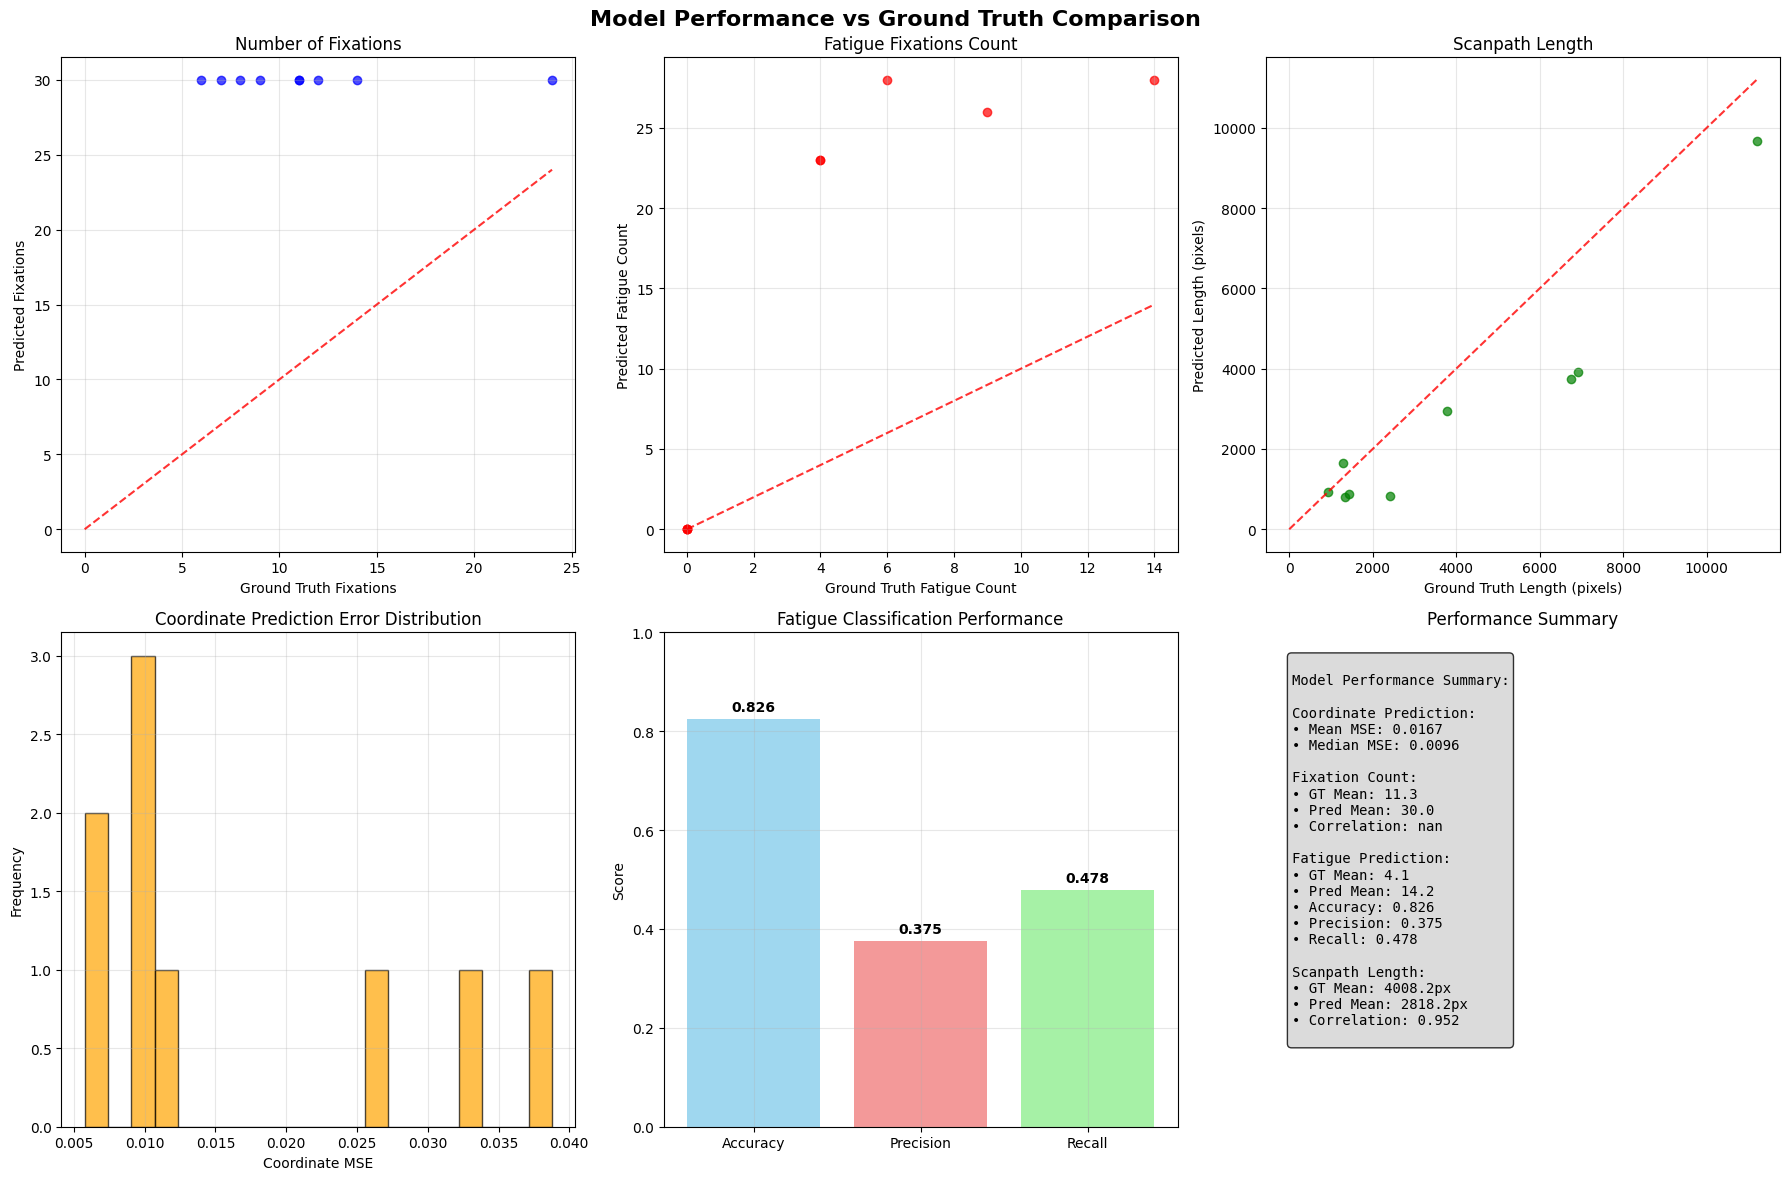


DETAILED EVALUATION RESULTS
📊 Evaluated 9 images
📈 Average Coordinate MSE: 0.0167
🎯 Average Fatigue Accuracy: 0.826
🔍 Average Fatigue Precision: 0.375
🔍 Average Fatigue Recall: 0.478
💾 Detailed results saved to outputs/evaluation_results.csv


In [23]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# ============================================================================
# Load the enhanced scanpath model from the provided .pth file
model_path = 'best_scanpath_model_enhanced.pth'
print(f"Loading enhanced scanpath model from {model_path}...")
# CELL 23: Load Models and Comprehensive Evaluation with Ground Truth Comparison
# ============================================================================

import matplotlib.pyplot as plt

# Load models (assuming they were defined in previous cells)
print("Loading trained models...")

# Load scanpath model
try:
    model.load_state_dict(torch.load('best_scanpath_model_enhanced.pth', map_location=device))
    print("✅ Loaded enhanced scanpath model")
except:
    try:
        model.load_state_dict(torch.load('best_scanpath_model.pth', map_location=device))
        print("✅ Loaded original scanpath model")
    except:
        print("❌ No scanpath model found!")

# Load fatigue model
try:
    fatigue_model.load_state_dict(torch.load('best_fatigue_model.pth', map_location=device))
    print("✅ Loaded fatigue model")
except:
    print("❌ No fatigue model found!")

model.eval()
fatigue_model.eval()

# Load ground truth data
with open('OUTPUT_SCANPATHS/scanpathsCAREFUL.json', 'r') as f:
    ground_truth = json.load(f)

print(f"📊 Loaded ground truth for {len(ground_truth)} images")

# Evaluation metrics storage
evaluation_results = {
    'image_name': [],
    'gt_num_fixations': [],
    'pred_num_fixations': [],
    'gt_fatigue_count': [],
    'pred_fatigue_count': [],
    'gt_scanpath_length': [],
    'pred_scanpath_length': [],
    'coordinate_mse': [],
    'fatigue_accuracy': [],
    'fatigue_precision': [],
    'fatigue_recall': []
}

# Process all images in displayFonts
images_dir = Path('dataset/displayFonts')
image_files = list(images_dir.glob('*.png')) + list(images_dir.glob('*.jpg'))

print(f"🔍 Found {len(image_files)} images to evaluate")

for img_path in image_files[:10]:  # Limit to first 10 for demo
    img_name = img_path.name
    
    if img_name not in ground_truth:
        print(f"⚠️ No ground truth for {img_name}, skipping...")
        continue
    
    print(f"\n📸 Processing {img_name}...")
    
    # Get ground truth for first variation
    gt_variations = ground_truth[img_name]
    gt_variation_key = list(gt_variations.keys())[0]
    gt_scanpath = gt_variations[gt_variation_key]
    
    if len(gt_scanpath) == 0:
        print(f"⚠️ Empty ground truth scanpath for {img_name}, skipping...")
        continue
    
    # Extract ground truth data
    gt_coords = [[fix[0], fix[1]] for fix in gt_scanpath]
    gt_labels = [1 if fix[3] == "Fatigue" else 0 for fix in gt_scanpath]
    gt_num_fixations = len(gt_coords)
    gt_fatigue_count = sum(gt_labels)
    gt_length = compute_scanpath_length(gt_coords)
    
    # Generate prediction
    try:
        predictions, img_size, original_image = predict_scanpath_variable_length(
            model, str(img_path), transform, device, 
            num_variations=1, min_fixations=10, max_fixations=30
        )
        
        pred_scanpath = predictions[0]
        pred_num_fixations = len(pred_scanpath)
        pred_length = compute_scanpath_length(pred_scanpath)
        
        # Predict fatigue labels
        pred_fatigue_labels = predict_fatigue(
            fatigue_model, transform(original_image), 
            pred_scanpath, img_size[0], img_size[1], device
        )
        pred_fatigue_count = sum(pred_fatigue_labels)
        
        # Calculate coordinate MSE (align lengths first)
        min_len = min(len(gt_coords), len(pred_scanpath))
        if min_len > 0:
            gt_coords_norm = np.array(gt_coords[:min_len]) / np.array([img_size[0], img_size[1]])
            pred_coords_norm = np.array(pred_scanpath[:min_len]) / np.array([img_size[0], img_size[1]])
            coord_mse = np.mean((gt_coords_norm - pred_coords_norm) ** 2)
        else:
            coord_mse = float('inf')
        
        # Calculate fatigue classification metrics
        min_fatigue_len = min(len(gt_labels), len(pred_fatigue_labels))
        if min_fatigue_len > 0:
            gt_labels_aligned = gt_labels[:min_fatigue_len]
            pred_labels_aligned = pred_fatigue_labels[:min_fatigue_len]
            
            # Calculate metrics
            correct = sum(1 for i in range(min_fatigue_len) if gt_labels_aligned[i] == pred_labels_aligned[i])
            fatigue_accuracy = correct / min_fatigue_len
            
            # Precision and recall for fatigue class
            tp = sum(1 for i in range(min_fatigue_len) if gt_labels_aligned[i] == 1 and pred_labels_aligned[i] == 1)
            fp = sum(1 for i in range(min_fatigue_len) if gt_labels_aligned[i] == 0 and pred_labels_aligned[i] == 1)
            fn = sum(1 for i in range(min_fatigue_len) if gt_labels_aligned[i] == 1 and pred_labels_aligned[i] == 0)
            
            fatigue_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            fatigue_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        else:
            fatigue_accuracy = fatigue_precision = fatigue_recall = 0
        
        # Store results
        evaluation_results['image_name'].append(img_name)
        evaluation_results['gt_num_fixations'].append(gt_num_fixations)
        evaluation_results['pred_num_fixations'].append(pred_num_fixations)
        evaluation_results['gt_fatigue_count'].append(gt_fatigue_count)
        evaluation_results['pred_fatigue_count'].append(pred_fatigue_count)
        evaluation_results['gt_scanpath_length'].append(gt_length)
        evaluation_results['pred_scanpath_length'].append(pred_length)
        evaluation_results['coordinate_mse'].append(coord_mse)
        evaluation_results['fatigue_accuracy'].append(fatigue_accuracy)
        evaluation_results['fatigue_precision'].append(fatigue_precision)
        evaluation_results['fatigue_recall'].append(fatigue_recall)
        
        print(f"  ✅ GT: {gt_num_fixations} fixations, {gt_fatigue_count} fatigue")
        print(f"  ✅ Pred: {pred_num_fixations} fixations, {pred_fatigue_count} fatigue")
        print(f"  ✅ Coord MSE: {coord_mse:.4f}, Fatigue Acc: {fatigue_accuracy:.3f}")
        
    except Exception as e:
        print(f"  ❌ Error processing {img_name}: {str(e)}")
        continue

# Convert to DataFrame for easier analysis
df_results = pd.DataFrame(evaluation_results)

print(f"\n📊 Evaluation completed for {len(df_results)} images")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance vs Ground Truth Comparison', fontsize=16, fontweight='bold')

# 1. Number of fixations comparison
axes[0, 0].scatter(df_results['gt_num_fixations'], df_results['pred_num_fixations'], alpha=0.7, color='blue')
axes[0, 0].plot([0, df_results['gt_num_fixations'].max()], [0, df_results['gt_num_fixations'].max()], 'r--', alpha=0.8)
axes[0, 0].set_xlabel('Ground Truth Fixations')
axes[0, 0].set_ylabel('Predicted Fixations')
axes[0, 0].set_title('Number of Fixations')
axes[0, 0].grid(True, alpha=0.3)

# 2. Fatigue count comparison
axes[0, 1].scatter(df_results['gt_fatigue_count'], df_results['pred_fatigue_count'], alpha=0.7, color='red')
axes[0, 1].plot([0, df_results['gt_fatigue_count'].max()], [0, df_results['gt_fatigue_count'].max()], 'r--', alpha=0.8)
axes[0, 1].set_xlabel('Ground Truth Fatigue Count')
axes[0, 1].set_ylabel('Predicted Fatigue Count')
axes[0, 1].set_title('Fatigue Fixations Count')
axes[0, 1].grid(True, alpha=0.3)

# 3. Scanpath length comparison
axes[0, 2].scatter(df_results['gt_scanpath_length'], df_results['pred_scanpath_length'], alpha=0.7, color='green')
axes[0, 2].plot([0, df_results['gt_scanpath_length'].max()], [0, df_results['gt_scanpath_length'].max()], 'r--', alpha=0.8)
axes[0, 2].set_xlabel('Ground Truth Length (pixels)')
axes[0, 2].set_ylabel('Predicted Length (pixels)')
axes[0, 2].set_title('Scanpath Length')
axes[0, 2].grid(True, alpha=0.3)

# 4. Coordinate MSE distribution
axes[1, 0].hist(df_results['coordinate_mse'], bins=20, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_xlabel('Coordinate MSE')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Coordinate Prediction Error Distribution')
axes[1, 0].grid(True, alpha=0.3)

# 5. Fatigue classification metrics
metrics_data = ['Accuracy', 'Precision', 'Recall']
metrics_values = [
    df_results['fatigue_accuracy'].mean(),
    df_results['fatigue_precision'].mean(),
    df_results['fatigue_recall'].mean()
]
bars = axes[1, 1].bar(metrics_data, metrics_values, color=['skyblue', 'lightcoral', 'lightgreen'], alpha=0.8)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Fatigue Classification Performance')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)
# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# 6. Overall summary statistics
summary_text = f"""
Model Performance Summary:

Coordinate Prediction:
• Mean MSE: {df_results['coordinate_mse'].mean():.4f}
• Median MSE: {df_results['coordinate_mse'].median():.4f}

Fixation Count:
• GT Mean: {df_results['gt_num_fixations'].mean():.1f}
• Pred Mean: {df_results['pred_num_fixations'].mean():.1f}
• Correlation: {df_results[['gt_num_fixations', 'pred_num_fixations']].corr().iloc[0,1]:.3f}

Fatigue Prediction:
• GT Mean: {df_results['gt_fatigue_count'].mean():.1f}
• Pred Mean: {df_results['pred_fatigue_count'].mean():.1f}
• Accuracy: {df_results['fatigue_accuracy'].mean():.3f}
• Precision: {df_results['fatigue_precision'].mean():.3f}
• Recall: {df_results['fatigue_recall'].mean():.3f}

Scanpath Length:
• GT Mean: {df_results['gt_scanpath_length'].mean():.1f}px
• Pred Mean: {df_results['pred_scanpath_length'].mean():.1f}px
• Correlation: {df_results[['gt_scanpath_length', 'pred_scanpath_length']].corr().iloc[0,1]:.3f}
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
axes[1, 2].set_xlim(0, 1)
axes[1, 2].set_ylim(0, 1)
axes[1, 2].axis('off')
axes[1, 2].set_title('Performance Summary')

plt.tight_layout()
plt.savefig('outputs/model_evaluation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed results
print("\n" + "="*80)
print("DETAILED EVALUATION RESULTS")
print("="*80)
print(f"📊 Evaluated {len(df_results)} images")
print(f"📈 Average Coordinate MSE: {df_results['coordinate_mse'].mean():.4f}")
print(f"🎯 Average Fatigue Accuracy: {df_results['fatigue_accuracy'].mean():.3f}")
print(f"🔍 Average Fatigue Precision: {df_results['fatigue_precision'].mean():.3f}")
print(f"🔍 Average Fatigue Recall: {df_results['fatigue_recall'].mean():.3f}")
print("="*80)

# Save results to CSV
df_results.to_csv('outputs/evaluation_results.csv', index=False)
print("💾 Detailed results saved to outputs/evaluation_results.csv")